<a href="https://colab.research.google.com/github/luccasnn/sistema-recomendacao/blob/main/sistema_recomendacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

!wget -q "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
!unzip -q ml-latest-small.zip

filmes = pd.read_csv("ml-latest-small/movies.csv")
ratings = pd.read_csv("ml-latest-small/ratings.csv")

print("Filmes:", filmes.shape)
print("Ratings:", ratings.shape)
print("\nFilmes:")
print(filmes.head())
print("\nRatings:")
print(ratings.head())

Filmes: (9742, 3)
Ratings: (100836, 4)

Filmes:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

Ratings:
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [4]:
print("Total de filmes:", len(filmes))
print("Total de ratings:", len(ratings))
print("Total de usuários:", ratings['userId'].nunique())
print("\nEstatísticas dos ratings:")
print(ratings['rating'].describe())

Total de filmes: 9742
Total de ratings: 100836
Total de usuários: 610

Estatísticas dos ratings:
count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


In [5]:
# junta os filmes com ratings
df = ratings.merge(filmes, on='movieId')

# filtra filmes com pelo menos 50 avaliações e usuários com pelo menos 50 avaliações
filmes_populares = df.groupby('title').filter(lambda x: len(x) >= 50)
usuarios_ativos = filmes_populares.groupby('userId').filter(lambda x: len(x) >= 50)

print("Registros após filtro:", len(usuarios_ativos))
print("Filmes:", usuarios_ativos['title'].nunique())
print("Usuários:", usuarios_ativos['userId'].nunique())

# matriz usuário x filme
matriz = usuarios_ativos.pivot_table(index='userId', columns='title', values='rating')
print("\nShape da matriz:", matriz.shape)

Registros após filtro: 33001
Filmes: 450
Usuários: 268

Shape da matriz: (268, 450)


In [8]:
# preenche nulos com 0 e calcula similaridade entre filmes
matriz_filled = matriz.fillna(0)
similaridade = cosine_similarity(matriz_filled.T)
df_similaridade = pd.DataFrame(similaridade, index=matriz.columns, columns=matriz.columns)

# função de recomendação
def recomendar(titulo, n=5):
    if titulo not in df_similaridade.columns:
        return f"Filme '{titulo}' não encontrado."

    similares = df_similaridade[titulo].sort_values(ascending=False)[1:n+1]
    return pd.DataFrame({'Filme': similares.index, 'Similaridade': similares.values.round(3)})

# testa com alguns dos filmes
print("=== Recomendações para Toy Story (1995) ===")
print(recomendar("Toy Story (1995)"))

print("\n=== Recomendações para The Matrix (1999) ===")
print(recomendar("Matrix, The (1999)"))

=== Recomendações para Toy Story (1995) ===
                                               Filme  Similaridade
0                               Jurassic Park (1993)         0.720
1                                Forrest Gump (1994)         0.693
2          Star Wars: Episode IV - A New Hope (1977)         0.674
3  Star Wars: Episode VI - Return of the Jedi (1983)         0.673
4                                Pulp Fiction (1994)         0.667

=== Recomendações para The Matrix (1999) ===
                                               Filme  Similaridade
0                                  Fight Club (1999)         0.818
1  Star Wars: Episode V - The Empire Strikes Back...         0.788
2          Star Wars: Episode IV - A New Hope (1977)         0.785
3  Star Wars: Episode VI - Return of the Jedi (1983)         0.780
4                         Saving Private Ryan (1998)         0.771


In [7]:

print(matriz.columns[matriz.columns.str.contains('Matrix', case=False)].tolist())

['Matrix Reloaded, The (2003)', 'Matrix Revolutions, The (2003)', 'Matrix, The (1999)']


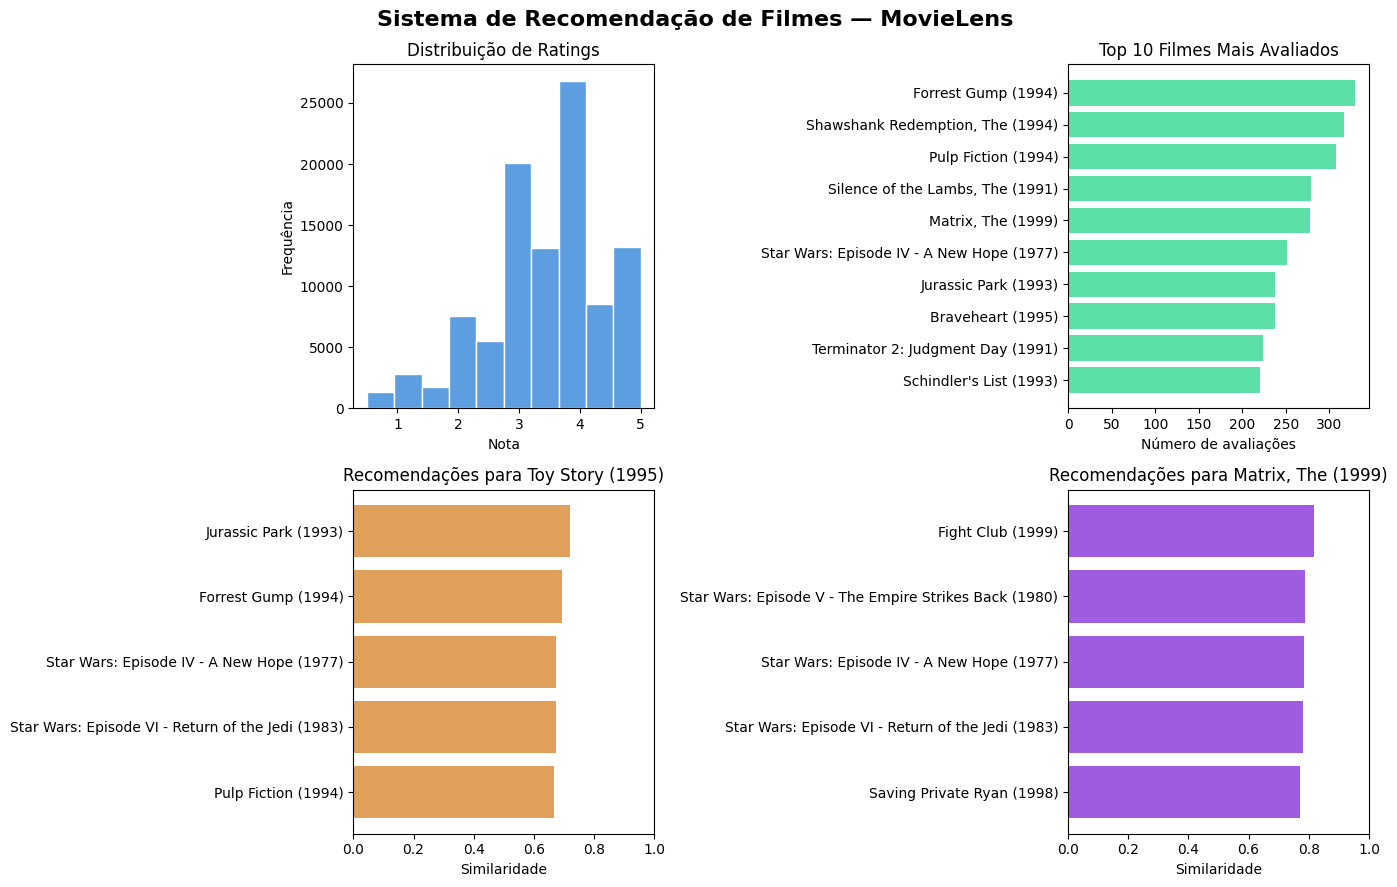

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Sistema de Recomendação de Filmes — MovieLens', fontsize=16, fontweight='bold')

#  ratings
axes[0, 0].hist(ratings['rating'], bins=10, color='#5c9ee0', edgecolor='white')
axes[0, 0].set_title('Distribuição de Ratings')
axes[0, 0].set_xlabel('Nota')
axes[0, 0].set_ylabel('Frequência')

#  mais avaliados
top_filmes = df.groupby('title')['rating'].count().sort_values(ascending=False).head(10)
axes[0, 1].barh(top_filmes.index, top_filmes.values, color='#5ce0a8')
axes[0, 1].set_title('Top 10 Filmes Mais Avaliados')
axes[0, 1].set_xlabel('Número de avaliações')
axes[0, 1].invert_yaxis()

# similares Toy Story
rec_toy = recomendar("Toy Story (1995)")
axes[1, 0].barh(rec_toy['Filme'], rec_toy['Similaridade'], color='#e0a05c')
axes[1, 0].set_title('Recomendações para Toy Story (1995)')
axes[1, 0].set_xlabel('Similaridade')
axes[1, 0].set_xlim(0, 1)
axes[1, 0].invert_yaxis()

# similares Matrix
rec_matrix = recomendar("Matrix, The (1999)")
axes[1, 1].barh(rec_matrix['Filme'], rec_matrix['Similaridade'], color='#a05ce0')
axes[1, 1].set_title('Recomendações para Matrix, The (1999)')
axes[1, 1].set_xlabel('Similaridade')
axes[1, 1].set_xlim(0, 1)
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig('sistema_recomendacao.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
from google.colab import files


files.download('sistema_recomendacao.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>